In [ ]:
import sys

if sys.platform == "emscripten":
    # Running in the browser (JupyterLite). ipywidgets has no prebuilt
    # Pyodide package, unlike numpy/pandas/scikit-learn/matplotlib
    # (preloaded by the JupyterLite build, see book/lite/overrides.json),
    # so it is fetched here instead of by a student-run install cell.
    # Local Jupyter and Colab already have ipywidgets installed.
    import micropip

    await micropip.install(["ipywidgets"])

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

_ABIDE_LITE_FEATURES = [
    'fsCT_L_1_ROI', 'fsCT_R_1_ROI', 'fsCT_L_10d_ROI', 'fsCT_R_10d_ROI',
    'fsCT_L_10pp_ROI', 'fsCT_R_10pp_ROI', 'fsCT_L_10r_ROI', 'fsCT_R_10r_ROI',
    'fsCT_L_10v_ROI', 'fsCT_R_10v_ROI', 'fsCT_L_11l_ROI', 'fsCT_R_11l_ROI',
    'fsCT_L_13l_ROI', 'fsCT_R_13l_ROI', 'fsCT_L_2_ROI', 'fsCT_R_2_ROI',
    'fsCT_L_23c_ROI', 'fsCT_R_23c_ROI', 'fsCT_L_23d_ROI', 'fsCT_R_23d_ROI',
    'fsCT_L_24dd_ROI', 'fsCT_R_24dd_ROI', 'fsCT_L_24dv_ROI', 'fsCT_R_24dv_ROI',
    'fsCT_L_25_ROI', 'fsCT_R_25_ROI', 'fsCT_L_31a_ROI', 'fsCT_R_31a_ROI',
    'fsCT_L_31pd_ROI', 'fsCT_R_31pd_ROI', 'fsCT_L_31pv_ROI', 'fsCT_R_31pv_ROI',
    'fsCT_L_33pr_ROI', 'fsCT_R_33pr_ROI', 'fsCT_L_3a_ROI', 'fsCT_R_3a_ROI',
    'fsCT_L_3b_ROI', 'fsCT_R_3b_ROI', 'fsCT_L_4_ROI', 'fsCT_R_4_ROI',
    'fsCT_L_43_ROI', 'fsCT_R_43_ROI', 'fsCT_L_44_ROI', 'fsCT_R_44_ROI',
    'fsCT_L_45_ROI', 'fsCT_R_45_ROI', 'fsCT_L_46_ROI', 'fsCT_R_46_ROI',
    'fsCT_L_47l_ROI', 'fsCT_R_47l_ROI', 'fsCT_L_47m_ROI', 'fsCT_R_47m_ROI',
    'fsCT_L_47s_ROI', 'fsCT_R_47s_ROI', 'fsCT_L_5L_ROI', 'fsCT_R_5R_ROI',
    'fsCT_L_52_ROI', 'fsCT_R_52_ROI', 'fsCT_L_55b_ROI', 'fsCT_R_55b_ROI',
    'fsCT_L_5m_ROI', 'fsCT_R_5m_ROI', 'fsCT_L_5mv_ROI', 'fsCT_R_5mv_ROI',
    'fsCT_L_6a_ROI', 'fsCT_R_6a_ROI', 'fsCT_L_6d_ROI', 'fsCT_R_6d_ROI',
    'fsCT_L_6ma_ROI', 'fsCT_R_6ma_ROI', 'fsCT_L_6mp_ROI', 'fsCT_R_6mp_ROI',
    'fsCT_L_6r_ROI', 'fsCT_R_6r_ROI', 'fsCT_L_6v_ROI', 'fsCT_R_6v_ROI',
    'fsCT_L_7AL_ROI', 'fsCT_R_7AL_ROI', 'fsCT_L_7Am_ROI', 'fsCT_R_7Am_ROI',
    'fsCT_L_7PC_ROI', 'fsCT_R_7PC_ROI', 'fsCT_L_7PL_ROI', 'fsCT_R_7PL_ROI',
    'fsCT_L_7Pm_ROI', 'fsCT_R_7Pm_ROI', 'fsCT_L_7m_ROI', 'fsCT_R_7m_ROI',
    'fsCT_L_8Ad_ROI', 'fsCT_R_8Ad_ROI', 'fsCT_L_8Av_ROI', 'fsCT_R_8Av_ROI',
    'fsCT_L_8BL_ROI', 'fsCT_R_8BL_ROI', 'fsCT_L_8BM_ROI', 'fsCT_R_8BM_ROI',
    'fsCT_L_8C_ROI', 'fsCT_R_8C_ROI', 'fsCT_L_9-46d_ROI', 'fsCT_R_9-46d_ROI',
    'fsCT_L_9a_ROI', 'fsCT_R_9a_ROI', 'fsCT_L_9m_ROI', 'fsCT_R_9m_ROI',
    'fsCT_L_9p_ROI', 'fsCT_R_9p_ROI', 'fsCT_L_A1_ROI', 'fsCT_R_A1_ROI',
    'fsCT_L_A4_ROI', 'fsCT_R_A4_ROI', 'fsCT_L_A5_ROI', 'fsCT_R_A5_ROI',
    'fsCT_L_AAIC_ROI', 'fsCT_R_AAIC_ROI', 'fsCT_L_AIP_ROI', 'fsCT_R_AIP_ROI',
    'fsCT_L_AVI_ROI', 'fsCT_R_AVI_ROI', 'fsCT_L_DVT_ROI', 'fsCT_R_DVT_ROI',
    'fsCT_L_EC_ROI', 'fsCT_R_EC_ROI', 'fsCT_L_FEF_ROI', 'fsCT_R_FEF_ROI',
    'fsCT_L_FFC_ROI', 'fsCT_R_FFC_ROI', 'fsCT_L_FOP1_ROI', 'fsCT_R_FOP1_ROI',
    'fsCT_L_FOP2_ROI', 'fsCT_R_FOP2_ROI', 'fsCT_L_FOP3_ROI', 'fsCT_R_FOP3_ROI',
    'fsCT_L_FOP4_ROI', 'fsCT_R_FOP4_ROI', 'fsCT_L_FOP5_ROI', 'fsCT_R_FOP5_ROI',
    'fsCT_L_FST_ROI', 'fsCT_R_FST_ROI', 'fsCT_L_H_ROI', 'fsCT_R_H_ROI',
    'fsCT_L_IFJa_ROI', 'fsCT_R_IFJa_ROI', 'fsCT_L_IFJp_ROI', 'fsCT_R_IFJp_ROI',
    'fsCT_L_IFSa_ROI', 'fsCT_R_IFSa_ROI', 'fsCT_L_IFSp_ROI', 'fsCT_R_IFSp_ROI',
    'fsCT_L_IP0_ROI', 'fsCT_R_IP0_ROI', 'fsCT_L_IP1_ROI', 'fsCT_R_IP1_ROI',
    'fsCT_L_IP2_ROI', 'fsCT_R_IP2_ROI', 'fsCT_L_IPS1_ROI', 'fsCT_R_IPS1_ROI',
    'fsCT_L_Ig_ROI', 'fsCT_R_Ig_ROI', 'fsCT_L_LBelt_ROI', 'fsCT_R_LBelt_ROI',
    'fsCT_L_LIPd_ROI', 'fsCT_R_LIPd_ROI', 'fsCT_L_LIPv_ROI', 'fsCT_R_LIPv_ROI',
    'fsCT_L_LO1_ROI', 'fsCT_R_LO1_ROI', 'fsCT_L_LO2_ROI', 'fsCT_R_LO2_ROI',
    'fsCT_L_LO3_ROI', 'fsCT_R_LO3_ROI', 'fsCT_L_MBelt_ROI', 'fsCT_R_MBelt_ROI',
    'fsCT_L_MI_ROI', 'fsCT_R_MI_ROI', 'fsCT_L_MIP_ROI', 'fsCT_R_MIP_ROI',
    'fsCT_L_MST_ROI', 'fsCT_R_MST_ROI', 'fsCT_L_MT_ROI', 'fsCT_R_MT_ROI',
    'fsCT_L_OFC_ROI', 'fsCT_R_OFC_ROI', 'fsCT_L_OP1_ROI', 'fsCT_R_OP1_ROI',
    'fsCT_L_OP2-3_ROI', 'fsCT_R_OP2-3_ROI', 'fsCT_L_OP4_ROI', 'fsCT_R_OP4_ROI',
    'fsCT_L_PBelt_ROI', 'fsCT_R_PBelt_ROI', 'fsCT_L_PCV_ROI', 'fsCT_R_PCV_ROI',
    'fsCT_L_PEF_ROI', 'fsCT_R_PEF_ROI', 'fsCT_L_PF_ROI', 'fsCT_R_PF_ROI',
    'fsCT_L_PFcm_ROI', 'fsCT_R_PFcm_ROI', 'fsCT_L_PFm_ROI', 'fsCT_R_PFm_ROI',
    'fsCT_L_PFop_ROI', 'fsCT_R_PFop_ROI', 'fsCT_L_PFt_ROI', 'fsCT_R_PFt_ROI',
    'fsCT_L_PGi_ROI', 'fsCT_R_PGi_ROI', 'fsCT_L_PGp_ROI', 'fsCT_R_PGp_ROI',
    'fsCT_L_PGs_ROI', 'fsCT_R_PGs_ROI', 'fsCT_L_PH_ROI', 'fsCT_R_PH_ROI',
    'fsCT_L_PHA1_ROI', 'fsCT_R_PHA1_ROI', 'fsCT_L_PHA2_ROI', 'fsCT_R_PHA2_ROI',
    'fsCT_L_PHA3_ROI', 'fsCT_R_PHA3_ROI', 'fsCT_L_PHT_ROI', 'fsCT_R_PHT_ROI',
    'fsCT_L_PI_ROI', 'fsCT_R_PI_ROI', 'fsCT_L_PIT_ROI', 'fsCT_R_PIT_ROI',
    'fsCT_L_POS1_ROI', 'fsCT_R_POS1_ROI', 'fsCT_L_POS2_ROI', 'fsCT_R_POS2_ROI',
    'fsCT_L_PSL_ROI', 'fsCT_R_PSL_ROI', 'fsCT_L_PeEc_ROI', 'fsCT_R_PeEc_ROI',
    'fsCT_L_Pir_ROI', 'fsCT_R_Pir_ROI', 'fsCT_L_PoI1_ROI', 'fsCT_R_PoI1_ROI',
    'fsCT_L_PoI2_ROI', 'fsCT_R_PoI2_ROI', 'fsCT_L_PreS_ROI', 'fsCT_R_PreS_ROI',
    'fsCT_L_ProS_ROI', 'fsCT_R_ProS_ROI', 'fsCT_L_RI_ROI', 'fsCT_R_RI_ROI',
    'fsCT_L_RSC_ROI', 'fsCT_R_RSC_ROI', 'fsCT_L_SCEF_ROI', 'fsCT_R_SCEF_ROI',
    'fsCT_L_SFL_ROI', 'fsCT_R_SFL_ROI', 'fsCT_L_STGa_ROI', 'fsCT_R_STGa_ROI',
    'fsCT_L_STSda_ROI', 'fsCT_R_STSda_ROI', 'fsCT_L_STSdp_ROI', 'fsCT_R_STSdp_ROI',
    'fsCT_L_STSva_ROI', 'fsCT_R_STSva_ROI', 'fsCT_L_STSvp_ROI', 'fsCT_R_STSvp_ROI',
    'fsCT_L_STV_ROI', 'fsCT_R_STV_ROI', 'fsCT_L_TA2_ROI', 'fsCT_R_TA2_ROI',
    'fsCT_L_TE1a_ROI', 'fsCT_R_TE1a_ROI', 'fsCT_L_TE1m_ROI', 'fsCT_R_TE1m_ROI',
    'fsCT_L_TE1p_ROI', 'fsCT_R_TE1p_ROI', 'fsCT_L_TE2a_ROI', 'fsCT_R_TE2a_ROI',
    'fsCT_L_TE2p_ROI', 'fsCT_R_TE2p_ROI', 'fsCT_L_TF_ROI', 'fsCT_R_TF_ROI',
    'fsCT_L_TGd_ROI', 'fsCT_R_TGd_ROI', 'fsCT_L_TGv_ROI', 'fsCT_R_TGv_ROI',
    'fsCT_L_TPOJ1_ROI', 'fsCT_R_TPOJ1_ROI', 'fsCT_L_TPOJ2_ROI', 'fsCT_R_TPOJ2_ROI',
    'fsCT_L_TPOJ3_ROI', 'fsCT_R_TPOJ3_ROI', 'fsCT_L_V1_ROI', 'fsCT_R_V1_ROI',
    'fsCT_L_V2_ROI', 'fsCT_R_V2_ROI', 'fsCT_L_V3_ROI', 'fsCT_R_V3_ROI',
    'fsCT_L_V3A_ROI', 'fsCT_R_V3A_ROI', 'fsCT_L_V3B_ROI', 'fsCT_R_V3B_ROI',
    'fsCT_L_V3CD_ROI', 'fsCT_R_V3CD_ROI', 'fsCT_L_V4_ROI', 'fsCT_R_V4_ROI',
    'fsCT_L_V4t_ROI', 'fsCT_R_V4t_ROI', 'fsCT_L_V6_ROI', 'fsCT_R_V6_ROI',
    'fsCT_L_V6A_ROI', 'fsCT_R_V6A_ROI', 'fsCT_L_V7_ROI', 'fsCT_R_V7_ROI',
    'fsCT_L_V8_ROI', 'fsCT_R_V8_ROI', 'fsCT_L_VIP_ROI', 'fsCT_R_VIP_ROI',
    'fsCT_L_VMV1_ROI', 'fsCT_R_VMV1_ROI', 'fsCT_L_VMV2_ROI', 'fsCT_R_VMV2_ROI',
    'fsCT_L_VMV3_ROI', 'fsCT_R_VMV3_ROI', 'fsCT_L_VVC_ROI', 'fsCT_R_VVC_ROI',
    'fsCT_L_a10p_ROI', 'fsCT_R_a10p_ROI', 'fsCT_L_a24_ROI', 'fsCT_R_a24_ROI',
    'fsCT_L_a24pr_ROI', 'fsCT_R_a24pr_ROI', 'fsCT_L_a32pr_ROI', 'fsCT_R_a32pr_ROI',
    'fsCT_L_a47r_ROI', 'fsCT_R_a47r_ROI', 'fsCT_L_a9-46v_ROI', 'fsCT_R_a9-46v_ROI',
    'fsCT_L_d23ab_ROI', 'fsCT_R_d23ab_ROI', 'fsCT_L_d32_ROI', 'fsCT_R_d32_ROI',
    'fsCT_L_i6-8_ROI', 'fsCT_R_i6-8_ROI', 'fsCT_L_p10p_ROI', 'fsCT_R_p10p_ROI',
    'fsCT_L_p24_ROI', 'fsCT_R_p24_ROI', 'fsCT_L_p24pr_ROI', 'fsCT_R_p24pr_ROI',
    'fsCT_L_p32_ROI', 'fsCT_R_p32_ROI', 'fsCT_L_p32pr_ROI', 'fsCT_R_p32pr_ROI',
    'fsCT_L_p47r_ROI', 'fsCT_R_p47r_ROI', 'fsCT_L_p9-46v_ROI', 'fsCT_R_p9-46v_ROI',
    'fsCT_L_pOFC_ROI', 'fsCT_R_pOFC_ROI', 'fsCT_L_s32_ROI', 'fsCT_R_s32_ROI',
    'fsCT_L_s6-8_ROI', 'fsCT_R_s6-8_ROI', 'fsCT_L_v23ab_ROI', 'fsCT_R_v23ab_ROI',
]


def load_abide_age_brain_table():
    """Return the age/brain table: 360 cortical-thickness predictors, age,
    and group (autism/control, used only to reproduce the established
    train/test split -- never a model feature).

    Tries the small same-origin file this notebook ships next to first
    (JupyterLite, or a full local checkout); falls back to the same
    pinned, checksummed public source this course already uses elsewhere
    (a bare downloaded .ipynb, or Colab, neither of which has the sibling
    data file). Both paths return identically shaped, identically ordered
    columns, so the rest of this notebook never needs to know which one
    ran.
    """
    from pathlib import Path

    local_path = Path("data/abide_age_brain.csv")
    if local_path.exists():
        table = pd.read_csv(local_path)
    else:
        url = (
            "https://raw.githubusercontent.com/neurohackademy/nh2020-curriculum/"
            "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b/"
            "tu-machine-learning-yarkoni/data/abide2.tsv"
        )
        table = pd.read_csv(url, sep="\t")
    table = table.dropna(subset=["age"])
    return table[_ABIDE_LITE_FEATURES + ["age", "group"]].reset_index(drop=True)


def make_single_choice_question(prompt, options, correct_index, feedback_correct="Correct.", feedback_incorrect="Not quite -- try again."):
    """A compact single-choice checked question. Returns a widget to display()."""
    radio = widgets.RadioButtons(options=list(options), description="", layout=widgets.Layout(width="max-content"))
    button = widgets.Button(description="Check answer", button_style="primary")
    feedback = widgets.Output()

    def _on_click(_button):
        with feedback:
            feedback.clear_output(wait=True)
            print(feedback_correct if radio.index == correct_index else feedback_incorrect)

    button.on_click(_on_click)
    return widgets.VBox([widgets.HTML(f"<b>{prompt}</b>"), radio, button, feedback])


def make_multi_choice_question(prompt, options, correct_indices, feedback_correct="Correct.", feedback_incorrect="Not quite -- try again."):
    """A compact multiple-selection checked question. Returns a widget to display()."""
    correct = set(correct_indices)
    boxes = [widgets.Checkbox(value=False, description=opt, indent=False) for opt in options]
    button = widgets.Button(description="Check answer", button_style="primary")
    feedback = widgets.Output()

    def _on_click(_button):
        selected = {i for i, cb in enumerate(boxes) if cb.value}
        with feedback:
            feedback.clear_output(wait=True)
            print(feedback_correct if selected == correct else feedback_incorrect)

    button.on_click(_on_click)
    return widgets.VBox([widgets.HTML(f"<b>{prompt}</b>")] + boxes + [button, feedback])


# Exercise 2: Regression and Bias-Variance Trade-Off


## What this notebook covers

You will use linear regression and k-nearest-neighbours (KNN) regression to
predict a participant's **age** from their ABIDE-II brain measurements. Some
cells are supplied and ready to run; others ask you to write a few lines
yourself, answer a question in writing, or answer a checked question with
immediate feedback. Along the way you will explore how model complexity
trades bias against variance.


## Section 1 — Load data and prepare the split


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [ ]:
# Load the established ABIDE-II age/brain table.
data = load_abide_age_brain_table()
FEATURES = [c for c in data.columns if c not in ("age", "group")]
print(f"{len(data)} participants, {len(FEATURES)} brain predictors")
data.head()


In [ ]:
# Define the target (age) and the feature matrix, then make the established
# reproducible split: 25% held out, stratified by diagnostic group so train
# and test have a similar autism/control mix.
X = data[FEATURES].to_numpy()
y = data["age"].to_numpy()
groups = data["group"].to_numpy()

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.25, random_state=42, stratify=groups
)
print(f"n_train = {len(y_train)}   n_test = {len(y_test)}")


In [ ]:
# Fit the scaler on training predictors only, then transform both sets.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Section 2 — Inspect the split before modelling


A practical check before fitting anything: are the train and test targets reasonably similar, and which features look related to age?


### Activity 2A — Compare target distributions


Write code that:
- plots `y_train` and `y_test` using the **same bins and axis range**;
- reports n, mean, standard deviation, minimum, and maximum for each;
- uses readable labels and a legend.


In [ ]:
# YOUR CODE HERE


> Are the two distributions similar enough for this exercise? Name one similarity and one difference. Do not choose model settings from the test distribution.

YOUR ANSWER HERE


In [ ]:
display(make_multi_choice_question(
    "Which uses of the test target y_test are allowed at this point in the notebook?",
    [
        "Plotting its distribution to sanity-check the split (as above).",
        "Choosing which features to use because they correlate well with y_test.",
        "Reporting its mean and standard deviation.",
        "Tuning the model's settings so the test score looks better.",
    ],
    correct_indices={0, 2},
))


### Activity 2B — Find features correlated with age


Write **training-only** code that:
- calculates the Pearson correlation between every brain feature and `y_train`;
- sorts by absolute correlation;
- displays and plots the ten strongest relationships, preserving sign;
- uses shortened, readable region labels.


In [ ]:
# YOUR CODE HERE


> Which two or three features do you expect to have large fitted coefficients, and why?

YOUR ANSWER HERE


## Section 3 — Fit linear regression


This is your first regression workflow, so it is supplied in full.


In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
test_r2 = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
print(f"held-out R^2 = {test_r2:.3f}")
print(f"held-out MSE = {test_mse:.1f}  (RMSE {test_mse ** 0.5:.1f} years)")


### Activity 3A — Inspect coefficients


Write code that:
- pairs the 360 feature names with their fitted coefficients;
- sorts by absolute magnitude;
- selects a readable number of the largest positive and negative coefficients;
- draws a labelled horizontal bar plot;
- describes the coefficient axis correctly for **standardized** predictors.


In [ ]:
# YOUR CODE HERE


> Compare this ranking with Activity 2B's correlation ranking. Which features appear on both lists, and which do not?

YOUR ANSWER HERE


In [ ]:
display(make_multi_choice_question(
    "Why can a feature's correlation with age and its fitted regression coefficient tell different stories?",
    [
        "Correlation is a marginal (feature-by-itself) relationship; a coefficient is conditional on every other feature already being in the model.",
        "Correlated predictors can share credit: a coefficient can shrink even for a feature with a strong marginal correlation once correlated neighbours absorb that signal.",
        "Coefficients are computed on the test set, so they answer a different question than a training-only correlation.",
        "The two measures are mathematically identical whenever the model is linear.",
    ],
    correct_indices={0, 1},
))


Marginal correlations and multivariable coefficients need not rank features identically -- a feature can correlate strongly with age on its own yet receive a small coefficient once correlated neighbouring regions are already in the model, and vice versa.


### Activity 3B — Create an observed-versus-predicted plot


Create an observed-versus-predicted scatter plot from `y_test` and `y_pred`.
Your plot should have:

- observed age on the x-axis, predicted age on the y-axis;
- a visible perfect-prediction diagonal;
- readable axis labels;
- a useful title.

For reference, here is the approved current result:


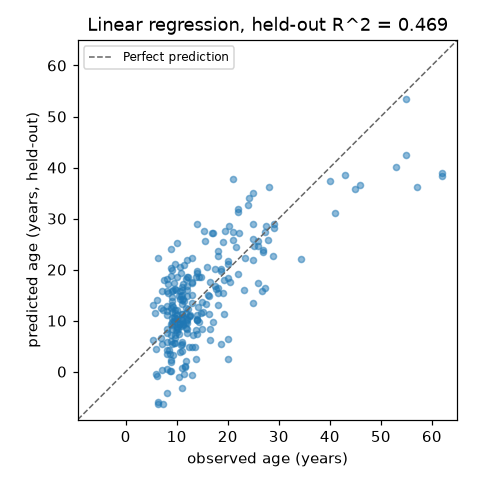


In [ ]:
# YOUR CODE HERE


> How closely do the held-out points track the diagonal? Where do the largest errors fall?

YOUR ANSWER HERE


## Section 4 — Correct and misleading evaluation


Same fixed split, same recipe, three ways to score the same model.


In [ ]:
train_pred = model.predict(X_train_scaled)
train_r2 = r2_score(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)

# A deliberately INVALID model: fit on the test rows, scored on those same
# test rows. Note n_test (251) is smaller than the number of features (360),
# so this fit is not just optimistic -- it is underdetermined.
invalid_model = LinearRegression().fit(X_test_scaled, y_test)
invalid_pred = invalid_model.predict(X_test_scaled)
invalid_r2 = r2_score(y_test, invalid_pred)
invalid_mse = mean_squared_error(y_test, invalid_pred)

comparison = pd.DataFrame(
    {
        "fit on": ["training rows", "training rows", "test rows (INVALID)"],
        "evaluated on": ["test rows", "training rows", "same test rows"],
        "R^2": [test_r2, train_r2, invalid_r2],
        "MSE": [test_mse, train_mse, invalid_mse],
    },
    index=["A. correct", "B. training score", "C. invalid"],
)
display(comparison.round(3))


**B is not a competing model.** A high training score next to a lower test score is the signature of a model fitting noise it cannot reproduce on new data. **C is not a competing model either** -- with 360 features and only 251 test rows, fitting on the test rows is underdetermined and reproduces those rows almost exactly, which is not the same as learning something that generalises.


In [ ]:
display(make_single_choice_question(
    "Which evaluation can estimate performance for a new participant?",
    ["A. correct", "B. training score", "C. invalid"],
    correct_index=0,
    feedback_correct="Correct: only scoring on held-out rows the model never touched during fitting estimates performance on a new participant.",
    feedback_incorrect="Not quite -- both training-row evaluation and fitting on test rows are misleading.",
))


## Section 5 — Build KNN regression yourselves


KNN predicts a participant's age from the ages of the `k` nearest training participants (by feature distance). `k` controls model complexity: it is yours to build this time.


Write code that:
1. imports `KNeighborsRegressor`;
2. creates a model with `k=20`;
3. fits it on `X_train_scaled` and `y_train`;
4. predicts `X_test_scaled`;
5. calculates R² and MSE;
6. produces an observed-versus-predicted plot;
7. compares it with linear regression in the answer cell below.


In [ ]:
# YOUR CODE HERE
# from sklearn.neighbors import ...
# knn_model = ...
# knn_pred = ...
# knn_r2 = ...
# knn_mse = ...


> How does KNN (k=20) compare with linear regression on this same split?

YOUR ANSWER HERE


In [ ]:
# A graceful check: verifies your KNN result without breaking later,
# independent sections if something above is still incomplete.
if "knn_pred" in globals() and "knn_r2" in globals():
    assert len(knn_pred) == len(y_test), "knn_pred should have one prediction per test row"
    assert np.isfinite(knn_r2) and np.isfinite(knn_mse), "R^2 and MSE should be finite numbers"
    print("Looks good: knn_pred, knn_r2, and knn_mse are all present and finite.")
else:
    print("Not complete yet: define knn_pred, knn_r2, and knn_mse above first.")


## Section 6 — Bias and variance


For a model predicting outcome $Y$ from features $X$, the expected squared
prediction error on a new observation decomposes as

$$\mathbb{E}\left[(Y-\hat f(X))^2\right] = \operatorname{Bias}(\hat f(X))^2 + \operatorname{Var}(\hat f(X)) + \sigma^2.$$

For KNN, `k` controls this directly:

- **small `k`** means greater model complexity, lower bias, and higher variance;
- **large `k`** means lower model complexity, higher bias, and lower variance.


In [ ]:
# CONCEPTUAL illustration only -- smooth idealised curves, not measured from
# the ABIDE data. Section 7 computes the empirical analogue.
flexibility = np.linspace(0.02, 1, 200)
bias_sq = (1 - flexibility) ** 2 * 2.2
variance = flexibility ** 2.2 * 2.0
irreducible = np.full_like(flexibility, 0.35)
expected_test_error = bias_sq + variance + irreducible

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(flexibility, bias_sq, label="squared bias", color="#2a6f9e")
ax.plot(flexibility, variance, label="variance", color="#b5622f")
ax.plot(flexibility, irreducible, label="irreducible error", color="0.6", ls=":")
ax.plot(flexibility, expected_test_error, label="expected test error", color="black", lw=2)
ax.set_xlabel("model flexibility (small k -> large k, right to left)")
ax.set_ylabel("error (schematic units)")
ax.set_title("The classic bias-variance tradeoff")
ax.legend(fontsize=8)
plt.show()


In [ ]:
display(make_single_choice_question(
    "Which of these changes increases KNN's model complexity?",
    ["Decreasing k", "Increasing k", "Model complexity does not depend on k"],
    correct_index=0,
))


## Section 7 — Performance across model complexity


In [ ]:
# This section uses only the outer-training partition (X_train, y_train) --
# the outer test set from Sections 3-5 is never touched here. Split it again
# into a fitting group and a validation group.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=7, stratify=groups_train
)
N_FIT = len(y_fit)

scaler_dev = StandardScaler().fit(X_fit)
Xf = scaler_dev.transform(X_fit)
Xv = scaler_dev.transform(X_val)


def _sorted_neighbor_targets(X_query, X_ref, y_ref):
    d = np.linalg.norm(X_query[:, None, :] - X_ref[None, :, :], axis=2)
    order = np.argsort(d, axis=1, kind="stable")
    return y_ref[order]


sorted_val = _sorted_neighbor_targets(Xv, Xf, y_fit)
sorted_fit = _sorted_neighbor_targets(Xf, Xf, y_fit)
ks = np.arange(1, N_FIT + 1)
val_pred_by_k = np.cumsum(sorted_val, axis=1) / ks
fit_pred_by_k = np.cumsum(sorted_fit, axis=1) / ks
val_mse = ((val_pred_by_k - y_val[:, None]) ** 2).mean(axis=0)
fit_mse = ((fit_pred_by_k - y_fit[:, None]) ** 2).mean(axis=0)
val_optimal_k = int(ks[np.argmin(val_mse)])
print(f"fitting participants = {N_FIT}   validation participants = {len(y_val)}")
print(f"k with lowest validation error = {val_optimal_k}")


In [ ]:
# Model complexity increases as k decreases, so plot against 1/k and let
# larger complexity run left to right. Integer k values stay visible as
# tick labels on a companion top axis.
complexity = 1.0 / ks

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(complexity, fit_mse, label="fitting MSE (resubstitution)", color="#2a6f9e")
ax.plot(complexity, val_mse, label="validation MSE", color="#b5622f")
ax.axvline(1.0 / val_optimal_k, color="0.6", lw=1, ls=":")
ax.set_xlabel("Model complexity")
ax.set_ylabel("mean squared error (years$^2$)")
ax.set_title("Fitting vs. validation error across model complexity")
ax.legend(fontsize=8)

k_ticks = [N_FIT, 100, 20, val_optimal_k, 5, 1]
k_ticks = sorted(set(k for k in k_ticks if 1 <= k <= N_FIT))
ax_top = ax.secondary_xaxis("top", functions=(lambda c: 1.0 / c, lambda k: 1.0 / k))
ax_top.set_xticks(k_ticks)
ax_top.set_xlabel("k (for reference)")
plt.tight_layout()
plt.show()


Fitting error keeps falling as complexity grows (perfect at k=1, the same resubstitution optimism from Section 4) while validation error is lowest at an intermediate complexity and rises again toward both ends -- the empirical signature of the classic bias-variance curve from Section 6.


## Section 8 — Explore model complexity


Move the slider or type a value to refit KNN at a different `k` and watch the observed-versus-predicted plot and the error curve position change together. Three deterministic training-sample resamples are overlaid so you can see how much predictions shift at a given `k` just from which fitting participants happened to be drawn.


In [ ]:
# This activity's own KNN fits do not depend on Section 5's import: it runs
# correctly whether or not you have completed that activity yet.
from sklearn.neighbors import KNeighborsRegressor

_rng = np.random.default_rng(41)
_resample_idx = [_rng.choice(N_FIT, size=N_FIT, replace=True) for _ in range(3)]
_resample_colors = ["#2a6f9e", "#b5622f", "#4c9a5b"]

k_slider = widgets.IntSlider(value=20, min=1, max=N_FIT, step=1, description="k:")
k_input = widgets.BoundedIntText(value=20, min=1, max=N_FIT, description="k (exact):")
k_output = widgets.Output()


def _explore_refit(k):
    with k_output:
        k_output.clear_output(wait=True)
        fig, (ax_scatter, ax_curve) = plt.subplots(1, 2, figsize=(10, 4))

        for idx, color in zip(_resample_idx, _resample_colors):
            model_r = KNeighborsRegressor(n_neighbors=k).fit(Xf[idx], y_fit[idx])
            pred_r = model_r.predict(Xv)
            ax_scatter.scatter(y_val, pred_r, s=12, alpha=0.5, color=color)
        lims = [y_val.min() - 3, y_val.max() + 3]
        ax_scatter.plot(lims, lims, "--", color="0.4", lw=1)
        ax_scatter.set_xlim(lims)
        ax_scatter.set_ylim(lims)
        ax_scatter.set_aspect("equal")
        ax_scatter.set_xlabel("observed age (years)")
        ax_scatter.set_ylabel("predicted age (years)")
        ax_scatter.set_title(f"k={k}  (three training-sample resamples)")

        ax_curve.plot(1.0 / ks, fit_mse, color="#2a6f9e", label="fitting MSE")
        ax_curve.plot(1.0 / ks, val_mse, color="#b5622f", label="validation MSE")
        ax_curve.axvline(1.0 / k, color="black", lw=1.5)
        ax_curve.set_xlabel("Model complexity")
        ax_curve.set_ylabel("mean squared error (years$^2$)")
        ax_curve.set_title("Your current k on the error curve")
        ax_curve.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
        print(f"k = {k}   model complexity (1/k) = {1.0 / k:.3f}")


def _on_k_change(change):
    if change["name"] == "value":
        k_input.value = change["new"]
        k_slider.value = change["new"]
        _explore_refit(change["new"])


k_slider.observe(_on_k_change, names="value")
k_input.observe(_on_k_change, names="value")
display(widgets.VBox([k_slider, k_input, k_output]))
_explore_refit(k_slider.value)


In [ ]:
display(make_single_choice_question(
    "In this activity, what happens to the three training-sample resamples' scatter as k grows very large?",
    [
        "They converge toward the same near-constant predictions.",
        "They spread further apart from each other.",
        "They become identical to the k=1 scatter.",
    ],
    correct_index=0,
    feedback_correct="Correct: at large k every resample averages over nearly the whole fitting set, so predictions converge toward the fitting-set mean regardless of which participants happened to be resampled.",
))


## Bonus — Feature sets and sample size


This section is optional and not required for the core session, and it is a teaching demonstration, not a rigorous protocol: trying many feature sets or sample sizes below is exploratory comparison, not formal feature selection -- the held-out score of the best-looking option is not an unbiased estimate of its true performance. The 10-feature set below was fixed in advance and is not chosen by ranking feature correlations the way Activity 2B did.


In [ ]:
# A small, fixed 10-column cortical-thickness subset, unrelated to the
# 360-feature recipe used everywhere else in this notebook: the bilateral
# sensorimotor strip (primary motor cortex, BA4, plus primary somatosensory
# cortex BA 3a/3b/1/2).
SAMPLE_SIZE_ROIS = ["4", "3a", "3b", "1", "2"]
FEATURES_SS = [f"fsCT_{hemi}_{roi}_ROI" for roi in SAMPLE_SIZE_ROIS for hemi in ("L", "R")]

data_ss = data[FEATURES_SS + ["age", "group"]]
X_ss = data_ss[FEATURES_SS].to_numpy()
y_ss = data_ss["age"].to_numpy()
groups_ss = data_ss["group"].to_numpy()
X_train_ss, X_test_ss, y_train_ss, y_test_ss = train_test_split(
    X_ss, y_ss, test_size=0.25, random_state=42, stratify=groups_ss
)

sizes = [40, 60, 90, 130, 200, 300, len(y_train_ss)]
n_repeats = 15
rng = np.random.default_rng(11)
med_r2, lo_r2, hi_r2 = [], [], []

scaler_ss = StandardScaler().fit(X_train_ss)
X_train_ss_scaled = scaler_ss.transform(X_train_ss)
X_test_ss_scaled = scaler_ss.transform(X_test_ss)

for n in sizes:
    scores = []
    for _ in range(n_repeats):
        idx = rng.choice(len(y_train_ss), size=min(n, len(y_train_ss)), replace=False)
        m = LinearRegression().fit(X_train_ss_scaled[idx], y_train_ss[idx])
        scores.append(r2_score(y_test_ss, m.predict(X_test_ss_scaled)))
    scores = np.array(scores)
    med_r2.append(np.median(scores))
    lo_r2.append(np.percentile(scores, 10))
    hi_r2.append(np.percentile(scores, 90))

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(sizes, lo_r2, hi_r2, alpha=0.25, label="10th-90th percentile")
ax.plot(sizes, med_r2, "o-", label="median held-out R$^2$")
ax.axhline(0, color="0.5", lw=1, ls=":")
ax.set_xlabel("training-set size")
ax.set_ylabel("held-out R^2")
ax.set_title(f"Sample size vs. accuracy ({len(FEATURES_SS)}-feature sensorimotor recipe)")
ax.legend(fontsize=8)
plt.show()


Median held-out R² climbs and the 10th-90th percentile band narrows as the training set grows: repeated resampling reduces the influence of any one unusually easy or hard draw, so the typical trend is what matters. This is a property of this small, fixed 10-feature recipe -- it does not describe the whole-cortex 360-feature recipe used everywhere else in this notebook.


## In summary

- A performance estimate that fits on training data and scores on data the
  model has never seen avoids inflated results; scoring on the fitting rows
  themselves inflates the number, whether those rows are the training set
  (optimistic) or, worse, the test set (invalid).
- `age` has a genuinely positive held-out R² from cortical thickness alone,
  for both linear regression and KNN.
- KNN's `k` directly controls model complexity: small `k` means high
  complexity, low bias, high variance; large `k` means low complexity,
  higher bias, lower variance.
